# XAI Results Analysis

This notebook explores the explanations generated by the pipeline across three angles:

1. **Cross-method feature importance** — Which features matter most across SHAP, LIME, and counterfactuals?
2. **SHAP vs LIME agreement** — Where do they agree and disagree, and why?
3. **Counterfactual insights** — How do the minimal changes relate to feature importance?

**Prerequisite:** Run `python xai_pipeline.py` first.

In [3]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# ── Re-run the pipeline but capture intermediate objects ──
# (We need the actual SHAP values, LIME weights, and CF results in memory)
from xai_pipeline import *

np.random.seed(42)

print('Loading data...')
X_tr, X_v, X_te, y_tr, y_v, y_te, feats = load_data()

print('Training model...')
model = build_cnn(X_tr.shape[1])
y_pred, y_prob, metrics = train_and_evaluate(model, X_tr, y_tr, X_v, y_v, X_te, y_te)

# Select samples
norm_idx = np.where((y_te == 0) & (y_pred == 0))[0]
att_idx  = np.where((y_te == 1) & (y_pred == 1))[0]
sel = np.concatenate([np.random.choice(norm_idx, 2, replace=False), np.random.choice(att_idx, 3, replace=False)])
X_exp = X_te[sel]
y_exp = y_te[sel]
labels = ['Normal' if y == 0 else 'Attack' for y in y_exp]

print('Generating explanations (this may take a few minutes)...')
shap_vals = run_shap(model, X_tr, X_exp, feats)
lime_wts  = run_lime(model, X_tr, X_exp, feats)
cf_res    = run_counterfactuals(model, X_exp, feats)

print('\nReady for analysis.')

Loading data...
  Train: 113375 | Val: 12598 | Test: 22544
Training model...
Epoch 1/30
443/443 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.9683 - loss: 0.0866 - val_accuracy: 0.9727 - val_loss: 0.1257 - learning_rate: 0.0010
Epoch 2/30
443/443 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.9811 - loss: 0.0522 - val_accuracy: 0.6060 - val_loss: 1.3995 - learning_rate: 0.0010
Epoch 3/30
443/443 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.9804 - loss: 0.0600 - val_accuracy: 0.8943 - val_loss: 0.3670 - learning_rate: 0.0010
Epoch 4/30
443/443 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.9782 - loss: 0.0730 - val_accuracy: 0.9804 - val_loss: 0.0568 - learning_rate: 0.0010
Epoch 5/30
443/443 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.9797 - loss: 0.0640 - val_accuracy: 0.9688 - val_loss: 0.0999 - learning_rate: 0.0010
Epoch 6/30
443/443 ━━━━━━━━━━━━━━━━━━━━ 13s 29ms/step - accuracy: 0.9829 - loss: 0.0542 - val_accuracy: 0.8273 - val_loss: 0.4325 - learning_rate: 0.0010

  0%|          | 0/5 [00:00<?, ?it/s]

  Saved SHAP plots for 5 samples

── LIME ──
  Saved LIME plots for 5 samples

── Counterfactuals ──
  Sample 0: failed in 500 iters
  Sample 1: failed in 500 iters
  Sample 2: flipped in 2 iters
  Sample 3: flipped in 51 iters
  Sample 4: flipped in 11 iters

Ready for analysis.


---
## 1. Cross-Method Feature Importance

Which features consistently matter across all three XAI methods? If SHAP, LIME, and counterfactuals all point to the same features, that's strong evidence those features genuinely drive the model's decisions.

In [7]:
# Aggregate importance from each method

# SHAP: mean |SHAP value| per feature
shap_imp = pd.Series(np.mean(np.abs(shap_vals), axis=0), index=feats).sort_values(ascending=False)

# LIME: mean |weight| per feature across all explained samples
lime_agg = {f: [] for f in feats}
for wt in lime_wts:
    for f in feats:
        lime_agg[f].append(abs(wt.get(f, 0)))
lime_imp = pd.Series({f: np.mean(v) for f, v in lime_agg.items()}).sort_values(ascending=False)

# Counterfactual: how often was each feature changed + avg magnitude
cf_freq = {f: 0 for f in feats}
cf_mag  = {f: [] for f in feats}
for r in cf_res:
    for f, delta in r['changes'].items():
        cf_freq[f] += 1
        cf_mag[f].append(abs(delta))
cf_imp = pd.Series({f: cf_freq[f] * np.mean(cf_mag[f]) if cf_mag[f] else 0 for f in feats}).sort_values(ascending=False)

# Combine into a single dataframe (normalise to 0-1 for comparison)
def normalise(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-10)

importance_df = pd.DataFrame({
    'SHAP': normalise(shap_imp),
    'LIME': normalise(lime_imp),
    'Counterfactual': normalise(cf_imp),
})
importance_df['Average'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('Average', ascending=False)

print('Top 15 features by cross-method average importance:\n')
print(importance_df.head(15).round(3).to_string())

Top 15 features by cross-method average importance:

                         SHAP   LIME  Counterfactual  Average
dst_host_rerror_rate    1.000  0.565           0.367    0.644
hot                     0.389  0.444           0.346    0.393
flag                    0.278  0.089           0.786    0.384
serror_rate             0.052  0.000           0.964    0.339
wrong_fragment          0.000  1.000           0.000    0.333
dst_host_diff_srv_rate  0.000  0.000           1.000    0.333
protocol_type           0.131  0.297           0.533    0.320
rerror_rate             0.420  0.000           0.459    0.293
dst_host_serror_rate    0.584  0.284           0.000    0.289
service                 0.276  0.000           0.504    0.260
same_srv_rate           0.260  0.083           0.428    0.257
count                   0.487  0.054           0.213    0.251
num_access_files        0.000  0.226           0.472    0.232
srv_serror_rate         0.169  0.162           0.306    0.212
logged_in        

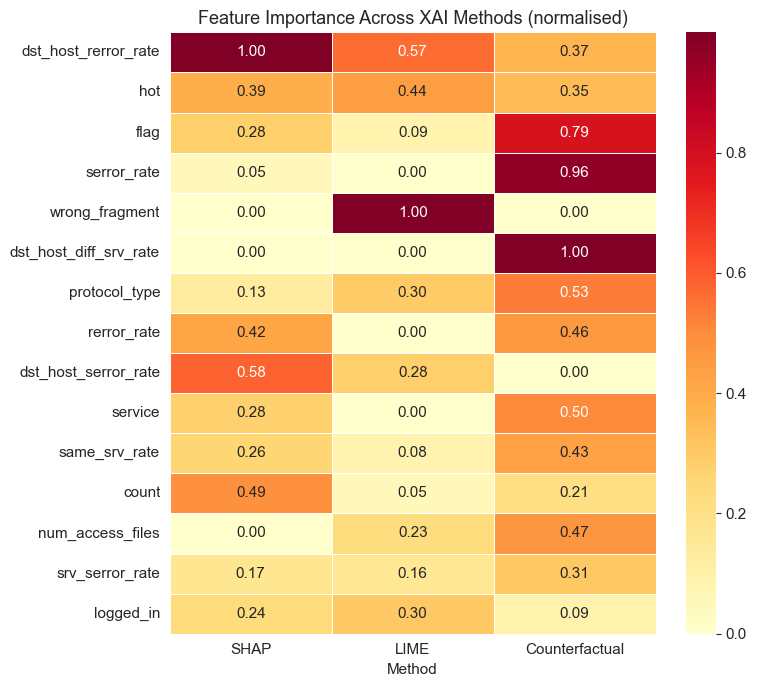

In [5]:
# Heatmap: top 15 features × 3 methods
top15 = importance_df.head(15)[['SHAP', 'LIME', 'Counterfactual']]

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(top15, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Feature Importance Across XAI Methods (normalised)', fontsize=13)
ax.set_xlabel('Method')
plt.tight_layout()
plt.savefig('results/cross_method_heatmap.png', dpi=150)
plt.show()

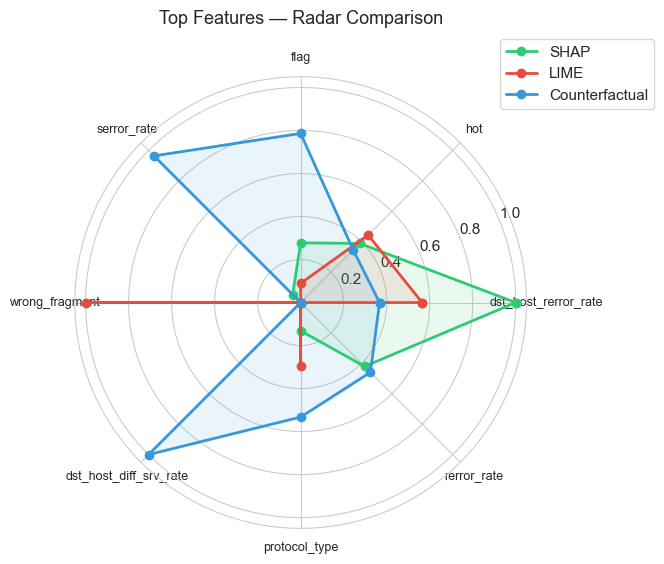

In [6]:
# Radar chart: top 8 features across methods
from matplotlib.patches import FancyBboxPatch

top8 = importance_df.head(8)
categories = list(top8.index)
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for method, color in [('SHAP', '#2ecc71'), ('LIME', '#e74c3c'), ('Counterfactual', '#3498db')]:
    vals = list(top8[method].values) + [top8[method].values[0]]
    ax.plot(angles, vals, 'o-', linewidth=2, label=method, color=color)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=9)
ax.set_title('Top Features — Radar Comparison', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('results/radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. SHAP vs LIME: Agreement & Disagreement

Do SHAP and LIME tell the same story? We look at this per-sample and globally.

In [ ]:
# Per-sample: top-10 Jaccard similarity + Spearman rank correlation
agreement_data = []

for i in range(len(X_exp)):
    shap_dict = dict(zip(feats, shap_vals[i]))
    lime_dict = lime_wts[i]
    
    # Top-10 features
    shap_top10 = set(sorted(feats, key=lambda f: abs(shap_dict[f]), reverse=True)[:10])
    lime_top10 = set(sorted(lime_dict, key=lambda f: abs(lime_dict[f]), reverse=True)[:10])
    
    jaccard = len(shap_top10 & lime_top10) / len(shap_top10 | lime_top10)
    overlap = shap_top10 & lime_top10
    shap_only = shap_top10 - lime_top10
    lime_only = lime_top10 - shap_top10
    
    # Rank correlation (over all shared features)
    common = set(shap_dict.keys()) & set(lime_dict.keys())
    if len(common) > 2:
        rho, _ = spearmanr([abs(shap_dict[f]) for f in common], [abs(lime_dict[f]) for f in common])
    else:
        rho = 0
    
    agreement_data.append({
        'sample': i,
        'label': labels[i],
        'jaccard': jaccard,
        'spearman': rho,
        'overlap': overlap,
        'shap_only': shap_only,
        'lime_only': lime_only,
    })

agree_df = pd.DataFrame(agreement_data)
print(agree_df[['sample', 'label', 'jaccard', 'spearman']].to_string(index=False))

In [ ]:
# Visualise agreement per sample
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.5))

colors = ['#2ecc71' if l == 'Normal' else '#e74c3c' for l in agree_df['label']]
x = range(len(agree_df))

a1.bar(x, agree_df['jaccard'], color=colors, edgecolor='white')
a1.set_title('Top-10 Feature Overlap (Jaccard)')
a1.set_xlabel('Sample'); a1.set_ylabel('Jaccard Similarity')
a1.set_ylim(0, 1); a1.set_xticks(list(x))
a1.axhline(y=agree_df['jaccard'].mean(), color='black', linestyle='--', alpha=0.5, label=f"mean={agree_df['jaccard'].mean():.2f}")
a1.legend()

a2.bar(x, agree_df['spearman'], color=colors, edgecolor='white')
a2.set_title('Rank Correlation (Spearman ρ)')
a2.set_xlabel('Sample'); a2.set_ylabel('Spearman ρ')
a2.set_ylim(-1, 1); a2.set_xticks(list(x))
a2.axhline(y=0, color='grey', linewidth=0.5)
a2.axhline(y=agree_df['spearman'].mean(), color='black', linestyle='--', alpha=0.5, label=f"mean={agree_df['spearman'].mean():.2f}")
a2.legend()

# Legend for colors
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color='#2ecc71', label='Normal'), Patch(color='#e74c3c', label='Attack')],
           loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.05))
plt.tight_layout()
plt.savefig('results/shap_lime_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Deep dive: for the sample with LOWEST agreement, show what each method focused on
worst_i = agree_df['jaccard'].idxmin()
row = agree_df.iloc[worst_i]

print(f"Sample {row['sample']} ({row['label']}) — Jaccard: {row['jaccard']:.2f}")
print(f"\n  Features BOTH methods agree on:  {row['overlap']}")
print(f"  SHAP only (LIME missed):          {row['shap_only']}")
print(f"  LIME only (SHAP missed):           {row['lime_only']}")

In [ ]:
# Side-by-side bar chart for that sample
i = worst_i
shap_dict = dict(zip(feats, shap_vals[i]))
lime_dict = lime_wts[i]

# Get union of top-10 from both
all_top = sorted(
    set(sorted(feats, key=lambda f: abs(shap_dict[f]), reverse=True)[:10]) |
    set(sorted(lime_dict, key=lambda f: abs(lime_dict[f]), reverse=True)[:10]),
    key=lambda f: abs(shap_dict[f]) + abs(lime_dict.get(f, 0)),
    reverse=True
)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
y = range(len(all_top))

a1.barh(y, [abs(shap_dict[f]) for f in all_top], color='#2ecc71', alpha=0.8)
a1.set_yticks(y); a1.set_yticklabels(all_top)
a1.set_xlabel('|SHAP value|'); a1.set_title(f'SHAP — Sample {i} ({labels[i]})')
a1.invert_yaxis()

a2.barh(y, [abs(lime_dict.get(f, 0)) for f in all_top], color='#e74c3c', alpha=0.8)
a2.set_xlabel('|LIME weight|'); a2.set_title(f'LIME — Sample {i} ({labels[i]})')

plt.suptitle(f'Lowest Agreement Sample — Where SHAP & LIME Disagree', fontsize=13)
plt.tight_layout()
plt.savefig('results/disagreement_deep_dive.png', dpi=150)
plt.show()

### Why might SHAP and LIME disagree?

Note your observations here after running. Common reasons include:
- **SHAP** captures global feature interactions (Shapley values account for all coalitions), while **LIME** fits a local linear approximation that may miss nonlinear interactions.
- LIME's perturbation sampling can under-weight rare but important features.
- Features that are correlated may get split credit differently by each method.

---
## 3. Counterfactual Insights vs Feature Importance

Counterfactuals answer a different question: *what needs to change?* Do the features that counterfactuals modify align with what SHAP/LIME say matters?

In [ ]:
# Build a per-sample comparison: SHAP rank vs CF change magnitude
cf_comparison = []

for i in range(len(X_exp)):
    if not cf_res[i]['success']:
        continue
    
    shap_rank = {f: rank for rank, f in enumerate(
        sorted(feats, key=lambda f: abs(dict(zip(feats, shap_vals[i]))[f]), reverse=True)
    )}
    
    for f, delta in cf_res[i]['changes'].items():
        cf_comparison.append({
            'sample': i,
            'label': labels[i],
            'feature': f,
            'cf_delta': abs(delta),
            'shap_rank': shap_rank.get(f, len(feats)),
            'shap_value': abs(dict(zip(feats, shap_vals[i])).get(f, 0)),
            'lime_weight': abs(lime_wts[i].get(f, 0)),
        })

cf_df = pd.DataFrame(cf_comparison)

if len(cf_df) > 0:
    print(f'{len(cf_df)} feature changes across {cf_df["sample"].nunique()} successful counterfactuals\n')
    print(cf_df.sort_values('cf_delta', ascending=False).head(15).to_string(index=False))
else:
    print('No successful counterfactuals — try increasing max_iter in the pipeline.')

In [ ]:
# Scatter: SHAP importance vs counterfactual change magnitude
if len(cf_df) > 0:
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5))

    a1.scatter(cf_df['shap_value'], cf_df['cf_delta'], 
               c=['#2ecc71' if l == 'Normal' else '#e74c3c' for l in cf_df['label']],
               alpha=0.6, s=60, edgecolors='white')
    a1.set_xlabel('|SHAP value|'); a1.set_ylabel('|Counterfactual Δ|')
    a1.set_title('SHAP Importance vs CF Change')
    # Add correlation
    if len(cf_df) > 2:
        rho, p = spearmanr(cf_df['shap_value'], cf_df['cf_delta'])
        a1.annotate(f'ρ = {rho:.2f} (p={p:.3f})', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10)

    a2.scatter(cf_df['lime_weight'], cf_df['cf_delta'],
               c=['#2ecc71' if l == 'Normal' else '#e74c3c' for l in cf_df['label']],
               alpha=0.6, s=60, edgecolors='white')
    a2.set_xlabel('|LIME weight|'); a2.set_ylabel('|Counterfactual Δ|')
    a2.set_title('LIME Importance vs CF Change')
    if len(cf_df) > 2:
        rho2, p2 = spearmanr(cf_df['lime_weight'], cf_df['cf_delta'])
        a2.annotate(f'ρ = {rho2:.2f} (p={p2:.3f})', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10)

    fig.legend(handles=[Patch(color='#2ecc71', label='Normal'), Patch(color='#e74c3c', label='Attack')],
               loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.05))
    plt.tight_layout()
    plt.savefig('results/cf_vs_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# Are the features that counterfactuals change actually the "important" ones?
if len(cf_df) > 0:
    cf_features = set(cf_df['feature'].unique())
    shap_top15 = set(shap_imp.head(15).index)
    lime_top15 = set(lime_imp.head(15).index)

    print(f'Features changed by counterfactuals: {len(cf_features)}')
    print(f'  Overlap with SHAP top-15:  {len(cf_features & shap_top15)} / {len(cf_features)}  ({len(cf_features & shap_top15)/len(cf_features)*100:.0f}%)')
    print(f'  Overlap with LIME top-15:  {len(cf_features & lime_top15)} / {len(cf_features)}  ({len(cf_features & lime_top15)/len(cf_features)*100:.0f}%)')
    print(f'  In all three methods:      {cf_features & shap_top15 & lime_top15}')
    print(f'  CF-only (not in SHAP/LIME top-15): {cf_features - shap_top15 - lime_top15}')

---
## 4. Summary Table

One table you can drop straight into your dissertation.

In [ ]:
report = json.load(open('results/report.json'))

summary = pd.DataFrame([
    {'Metric': 'Model Accuracy', 'Value': f"{report['model']['accuracy']:.4f}"},
    {'Metric': 'Model F1 (weighted)', 'Value': f"{report['model']['f1']:.4f}"},
    {'Metric': 'Model AUC-ROC', 'Value': f"{report['model']['auc']:.4f}"},
    {'Metric': 'SHAP Fidelity (mean)', 'Value': f"{report['evaluation']['shap_fidelity']:.4f}"},
    {'Metric': 'LIME Fidelity (mean)', 'Value': f"{report['evaluation']['lime_fidelity']:.4f}"},
    {'Metric': 'SHAP–LIME Consistency (Jaccard@10)', 'Value': f"{report['evaluation']['consistency']:.4f}"},
    {'Metric': 'SHAP–LIME Rank Correlation (mean)', 'Value': f"{agree_df['spearman'].mean():.4f}"},
    {'Metric': 'Counterfactual Success Rate', 'Value': f"{report['counterfactuals']['success_rate']:.1%}"},
])

print(summary.to_string(index=False))

---
## 5. Your Observations

Use this section to record your findings. Some prompts:

- **Cross-method agreement:** Which features appeared in all three methods' top lists? What does this suggest about the model's decision-making?
- **Disagreements:** Where SHAP and LIME diverge, is one method capturing feature interactions the other misses?
- **Counterfactual actionability:** Are the features that need to change to flip a prediction realistic? (e.g., can an attacker actually modify `dst_host_srv_count`?)
- **Normal vs Attack:** Do explanations differ structurally between correctly classified normal and attack traffic?
- **Implications for trust:** Based on these results, which XAI method would you recommend to a network security analyst, and why?

In [ ]:
# Space for your notes
observations = """
TODO: Fill in after reviewing the plots above.
"""
print(observations)